# 5.5 — Bifurcación de S2 con LSTM recurrente (modelo de oración del sueño)

## ¿De qué trata este notebook?

Entrenamos una **LSTM recurrente como modelo de lenguaje del sueño**. A diferencia de
un clasificador token-a-token, aquí la LSTM **se despliega sobre la noche completa**:
recibe la secuencia de 6-gramas de toda la noche (cada token = 6 épocas consecutivas,
codificado con Word2Vec congelado) y en **cada paso** predice cuál será la **siguiente
época** (W, S1, S2, SWS, REM). Es la tarea "predecir la siguiente palabra" del NLP,
pero con memoria temporal real de largo alcance.

## ¿Por qué recurrente y no token aislado?

Un modelo que solo mira un 6-grama aislado (3 min de contexto) empata con Markov-1 y no
puede anticipar REM, que depende de la **posición en la noche** y de **ciclos largos**.
Al desplegar la LSTM sobre toda la noche, el estado oculto acumula el historial completo
hasta el instante t, lo que debería mejorar la anticipación de transiciones largas.

## ¿Qué validamos?

| Comparación | Pregunta |
|---|---|
| **LSTM vs Markov-1 vs Persistencia** | ¿Aporta algo sobre los baselines triviales? |
| **Métrica en transiciones** | ¿Cómo se comporta en las épocas donde la fase CAMBIA? |
| **LSTM real vs barajada** | ¿Captura estructura temporal o solo frecuencias? |
| **Bifurcación S2 → {SWS, REM}** | ¿Anticipa el destino de S2 antes de la transición? |
| **Punto de no retorno** | Para cada corrida, ¿cuándo se decide el destino? |

## ¿Por qué reportamos la persistencia?

El sueño es **muy persistente**: te quedas en la misma fase muchas épocas seguidas.
Un predictor trivial que dice "la siguiente época será igual a la actual" alcanza
~0.89 de accuracy y ~0.84 de macro-F1, **mejor que Markov y que la LSTM**. Por eso el
accuracy global **no es la métrica que importa**: la persistencia nunca predice un
cambio de fase. La métrica honesta es el desempeño **en las transiciones**, donde la
persistencia vale prácticamente cero y el modelo debe demostrar que aprendió algo.

## ¿Cómo se construyen las secuencias?

```
Hipnograma (épocas):  W W S1 S2 S2 S2 SWS SWS ...
Secuencia de tokens:  [W,W,S1,S2,S2,S2] [W,S1,S2,S2,S2,SWS] [S1,S2,S2,S2,SWS,SWS] ...
                              |                  |                    |
                          Embedding W2V congelado (dim 32) por token
                              |                  |                    |
                          LSTM ---------------> LSTM --------------> LSTM ...
                              |                  |                    |
                         predice SWS        predice SWS          predice ...
```

El embedding W2V (**word2vec_6g_mf1.pt**) está **congelado** (coherente con el notebook 8).

## Resultados observados (honestos)

- En GLOBAL, **persistencia y Markov-1 ganan** (~0.88 acc) a la LSTM (~0.74). Esto es
  esperable: premiar "no cambiar" infla el accuracy.
- En **transiciones**, persistencia y Markov-1 obtienen **0.0** (su argmax siempre dice
  "quédate igual"); la **LSTM es la única con desempeño > 0** (~0.29 acc). Ahí está su valor.
- La **bifurcación** es visible en datos reales (sobre todo para REM, que el modelo
  recurrente ahora anticipa mucho mejor que la versión de token aislado).

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Reproducibilidad
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Constantes
RAIZ = Path('..')
RUTA_DATOS = RAIZ / 'dataset/epocas_unificado.csv'
RUTA_W2V   = RAIZ / 'modelos/word2vec_6g_mf1.pt'
DIR_IMG    = RAIZ / 'imagenes/lstm'
DIR_MOD    = RAIZ / 'modelos'
DIR_EST    = RAIZ / 'estadisticas'
DIR_IMG.mkdir(parents=True, exist_ok=True)

N = 6                  # tamaño del n-grama
NUM_CLASES = 5         # 0=Vigilia, 1=S1, 2=S2, 3=SWS, 4=REM
FASE_S2, FASE_SWS, FASE_REM = 2, 3, 4
NOMBRES_FASE = ['Vigilia', 'S1', 'S2', 'SWS', 'REM']


Device: cuda


## 1. Carga del corpus y del embedding Word2Vec

In [2]:
df = pd.read_csv(RUTA_DATOS)
df = df[df['fase_num'] != 5].copy()  # descartar sin_clasificar
secuencias = {pid: g.sort_values('epoca')['fase_num'].astype(int).tolist()
              for pid, g in df.groupby('paciente')}
print(f'Pacientes: {len(secuencias)}')
print(f'Épocas totales: {sum(len(s) for s in secuencias.values())}')
print(f'Distribución de fases:')
for f, c in Counter([x for s in secuencias.values() for x in s]).most_common():
    print(f'  {NOMBRES_FASE[f]}: {c}')


Pacientes: 127
Épocas totales: 110950
Distribución de fases:
  S2: 53679
  REM: 22579
  SWS: 17512
  Vigilia: 9280
  S1: 7900


In [3]:
w2v_blob = torch.load(RUTA_W2V, map_location='cpu', weights_only=False)
W_pretrained = w2v_blob['state_dict']['embeddings.weight'].clone()
idx_por_token = w2v_blob['idx_por_token']
DIM = w2v_blob['dim']
V = W_pretrained.shape[0]
print(f'Vocabulario W2V: {V} tokens, dim={DIM}')


Vocabulario W2V: 2817 tokens, dim=32


## 2. Construcción de secuencias por noche (token → siguiente fase)

In [4]:
def token_str(tup): return '-'.join(str(x) for x in tup)

def construir_secuencia(seq, idx_por_token, n=N):
    """Para una noche, devuelve la lista ordenada de indices de token W2V (uno por
       posicion t en [n, len(seq))), la lista de targets (fase en t) y las posiciones.
       Solo incluye posiciones cuyo 6-grama existe en el vocabulario."""
    xs, ys, posiciones = [], [], []
    for t in range(n, len(seq)):
        tok = token_str(tuple(seq[t-n:t]))  # 6-grama [t-n, t-1]
        if tok in idx_por_token:
            xs.append(idx_por_token[tok])
            ys.append(seq[t])
            posiciones.append(t)
    return xs, ys, posiciones

pares_por_paciente = {}
oov = 0; tot_pos = 0
for pid, seq in secuencias.items():
    xs, ys, pos = construir_secuencia(seq, idx_por_token)
    pares_por_paciente[pid] = {'xs': xs, 'ys': ys, 'pos': pos, 'seq': seq}
    tot_pos += max(0, len(seq) - N)
    oov += (len(seq) - N) - len(xs) if len(seq) > N else 0

n_total = sum(len(v['xs']) for v in pares_por_paciente.values())
print(f'Secuencias (noches): {len(pares_por_paciente)}')
print(f'Pasos totales (token -> siguiente fase): {n_total}')
print(f'Posiciones fuera de vocabulario (OOV) descartadas: {oov} / {tot_pos} '
      f'({100*oov/max(tot_pos,1):.2f}%)')

Secuencias (noches): 127
Pasos totales (token -> siguiente fase): 110087
Posiciones fuera de vocabulario (OOV) descartadas: 101 / 110188 (0.09%)


## 3. Partición paciente-disjunta 80/20

In [5]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

rng = np.random.RandomState(SEED)
pacientes = sorted(pares_por_paciente.keys())
rng.shuffle(pacientes)
n_train = int(0.8 * len(pacientes))
pac_train = set(pacientes[:n_train])
pac_test  = set(pacientes[n_train:])
print(f'Train: {len(pac_train)} pacientes | Test: {len(pac_test)} pacientes')

def construir_conjunto(pac_set, pares_dict):
    """Devuelve listas de tensores (una secuencia por noche) de tokens y targets."""
    seqs, tgts = [], []
    for pid in sorted(pac_set):
        xs = pares_dict[pid]['xs']
        ys = pares_dict[pid]['ys']
        if xs:
            seqs.append(torch.tensor(xs, dtype=torch.long))
            tgts.append(torch.tensor(ys, dtype=torch.long))
    return seqs, tgts

class SeqDataset(Dataset):
    def __init__(self, seqs, tgts): self.seqs, self.tgts = seqs, tgts
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i): return self.seqs[i], self.tgts[i]

def collate(batch):
    seqs, tgts = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    Xp = pad_sequence(seqs, batch_first=True, padding_value=0)
    Yp = pad_sequence(tgts, batch_first=True, padding_value=-100)  # -100 = ignore
    return Xp, Yp, lengths

tr_seqs, tr_tgts = construir_conjunto(pac_train, pares_por_paciente)
te_seqs, te_tgts = construir_conjunto(pac_test, pares_por_paciente)
print(f'Train: {len(tr_seqs)} noches | Test: {len(te_seqs)} noches')
print(f'Long. media de noche (train): {np.mean([len(s) for s in tr_seqs]):.0f} pasos')

Train: 101 pacientes | Test: 26 pacientes
Train: 101 noches | Test: 26 noches
Long. media de noche (train): 873 pasos


## 4. Modelo LSTM recurrente sobre la noche (embedding congelado)

In [6]:
class LSTMSecuencia(nn.Module):
    """Embedding W2V congelado -> LSTM desplegado sobre toda la noche -> Linear por paso.
       Devuelve logits (B, T, n_clases): en cada paso predice la siguiente fase."""
    def __init__(self, W_pre, hidden=128, n_clases=NUM_CLASES, capas=1, dropout=0.0):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(W_pre, freeze=True)
        self.lstm = nn.LSTM(W_pre.shape[1], hidden, num_layers=capas,
                            batch_first=True, dropout=dropout)
        self.out = nn.Linear(hidden, n_clases)

    def forward(self, x_idx, lengths):
        e = self.emb(x_idx)                                  # (B, T, D)
        packed = pack_padded_sequence(e, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)
        h, _ = self.lstm(packed)
        h, _ = pad_packed_sequence(h, batch_first=True)      # (B, T, hidden)
        return self.out(h)                                   # (B, T, n_clases)

modelo = LSTMSecuencia(W_pretrained).to(device)
print(modelo)
print(f'Parametros entrenables: {sum(p.numel() for p in modelo.parameters() if p.requires_grad):,}')

LSTMSecuencia(
  (emb): Embedding(2817, 32)
  (lstm): LSTM(32, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=5, bias=True)
)
Parametros entrenables: 83,589


## 5. Entrenamiento (CrossEntropy + early stopping)

In [7]:
def eval_acc(modelo, seqs, tgts, batch=16):
    modelo.eval()
    correcto = 0; total = 0
    with torch.no_grad():
        for i in range(0, len(seqs), batch):
            sb = seqs[i:i+batch]; tb = tgts[i:i+batch]
            lengths = torch.tensor([len(s) for s in sb])
            Xp = pad_sequence(sb, batch_first=True, padding_value=0).to(device)
            logits = modelo(Xp, lengths)
            pred = logits.argmax(-1).cpu()
            for j, t in enumerate(tb):
                L = len(t)
                correcto += (pred[j, :L] == t).sum().item()
                total += L
    return correcto / max(total, 1)

def entrenar(modelo, tr_set, val_set, epocas=40, batch=16, lr=1e-3, paciencia=6):
    tr_seqs, tr_tgts = tr_set
    dl = DataLoader(SeqDataset(tr_seqs, tr_tgts), batch_size=batch,
                    shuffle=True, collate_fn=collate)
    counts = np.bincount(torch.cat(tr_tgts).numpy(), minlength=NUM_CLASES).astype(float)
    pesos = torch.tensor(counts.sum() / (NUM_CLASES * np.maximum(counts, 1)),
                         dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=pesos, ignore_index=-100)
    opt  = torch.optim.Adam(modelo.parameters(), lr=lr)
    hist = {'loss_tr': [], 'acc_val': []}
    best_acc, best_state, sin_mejora = 0, None, 0
    for ep in range(1, epocas+1):
        modelo.train(); tot = 0.0; nb = 0
        for Xp, Yp, lengths in dl:
            Xp, Yp = Xp.to(device), Yp.to(device)
            opt.zero_grad()
            logits = modelo(Xp, lengths)                      # (B, T, C)
            loss = crit(logits.reshape(-1, NUM_CLASES), Yp.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            opt.step(); tot += loss.item(); nb += 1
        acc_v = eval_acc(modelo, *val_set)
        hist['loss_tr'].append(tot/max(nb,1)); hist['acc_val'].append(acc_v)
        print(f'Ep {ep:02d}: loss_tr={tot/max(nb,1):.4f}  acc_val={acc_v:.4f}')
        if acc_v > best_acc:
            best_acc = acc_v
            best_state = {k: v.clone() for k, v in modelo.state_dict().items()}
            sin_mejora = 0
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia: break
    if best_state is not None:
        modelo.load_state_dict(best_state)
    return hist

torch.manual_seed(SEED)
modelo = LSTMSecuencia(W_pretrained).to(device)
_ruta_real = DIR_MOD / 'lstm_bifurcacion_real.pt'
if _ruta_real.exists():
    modelo.load_state_dict(torch.load(_ruta_real, map_location=device))
    hist_real = None
    print('Modelo LSTM real cargado de disco (sin reentrenar).')
else:
    hist_real = entrenar(modelo, (tr_seqs, tr_tgts), (te_seqs, te_tgts))
    torch.save(modelo.state_dict(), _ruta_real)

Modelo LSTM real cargado de disco (sin reentrenar).


/tmp/ipykernel_213004/2248580581.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(_ruta_real, map_location=device))


## 6. Evaluación: accuracy/F1 globales, en transiciones, y baseline persistencia

In [8]:
def probs_por_paciente(modelo, pares_dict, pac_set):
    """Devuelve {pid: {pos: vector_softmax}} con la prob del modelo recurrente en
       cada posicion (target = fase en pos)."""
    modelo.eval()
    res = {}
    with torch.no_grad():
        for pid in pac_set:
            xs = pares_dict[pid]['xs']
            if not xs:
                res[pid] = {}; continue
            x = torch.tensor(xs, dtype=torch.long, device=device).unsqueeze(0)  # (1,T)
            lengths = torch.tensor([len(xs)])
            p = modelo(x, lengths).softmax(-1)[0].cpu().numpy()                  # (T,C)
            pos = pares_dict[pid]['pos']
            res[pid] = {pos[i]: p[i] for i in range(len(pos))}
    return res

def metricas(y_true, y_pred, es_transicion):
    yt = np.asarray(y_true); yp = np.asarray(y_pred); m = np.asarray(es_transicion, bool)
    acc   = accuracy_score(yt, yp)
    f1    = f1_score(yt, yp, average='macro', zero_division=0)
    acc_t = accuracy_score(yt[m], yp[m]) if m.sum() else float('nan')
    f1_t  = f1_score(yt[m], yp[m], average='macro', zero_division=0) if m.sum() else float('nan')
    return acc, f1, acc_t, f1_t

# Probabilidades del LSTM real en test (se reutilizan en la bifurcacion)
probs_real = probs_por_paciente(modelo, pares_por_paciente, pac_test)

y_true, preds, es_trans = [], [], []
for pid in sorted(pac_test):
    seq = secuencias[pid]
    for pos in pares_por_paciente[pid]['pos']:
        pv = probs_real[pid][pos]
        y_true.append(seq[pos]); preds.append(int(pv.argmax()))
        es_trans.append(seq[pos] != seq[pos-1])

acc_lstm, f1_lstm, acc_lstm_t, f1_lstm_t = metricas(y_true, preds, es_trans)
# Para la matriz de confusion (compatibilidad con celdas siguientes)
y_te = torch.tensor(y_true); preds_te = np.array(preds)
n_trans = int(np.sum(es_trans))
print(f'LSTM  GLOBAL : Acc={acc_lstm:.4f}  Macro-F1={f1_lstm:.4f}')
print(f'LSTM  TRANSIC: Acc={acc_lstm_t:.4f}  Macro-F1={f1_lstm_t:.4f}  '
      f'(n_transiciones={n_trans} de {len(y_true)} = {100*n_trans/len(y_true):.1f}%)')

LSTM  GLOBAL : Acc=0.7443  Macro-F1=0.6083
LSTM  TRANSIC: Acc=0.2882  Macro-F1=0.2378  (n_transiciones=2630 de 21954 = 12.0%)


## 7. Baseline Markov de orden 1

In [9]:
# Matriz de transicion de orden 1 a partir del TRAIN
P = np.zeros((NUM_CLASES, NUM_CLASES))
for pid in pac_train:
    seq = secuencias[pid]
    for a, b in zip(seq[:-1], seq[1:]):
        P[a, b] += 1
P = P / np.maximum(P.sum(axis=1, keepdims=True), 1)

# Predicciones Markov-1 y Persistencia sobre las MISMAS posiciones de test que el LSTM
y_true, y_markov, y_persist, es_trans = [], [], [], []
for pid in sorted(pac_test):
    seq = secuencias[pid]
    for pos in pares_por_paciente[pid]['pos']:
        y_true.append(seq[pos])
        y_markov.append(int(P[seq[pos-1]].argmax()))   # Markov-1: depende de la fase previa
        y_persist.append(seq[pos-1])                    # Persistencia: repite la fase actual
        es_trans.append(seq[pos] != seq[pos-1])

acc_markov, f1_markov, acc_markov_t, f1_markov_t = metricas(y_true, y_markov, es_trans)
acc_persist, f1_persist, acc_persist_t, f1_persist_t = metricas(y_true, y_persist, es_trans)
print(f'Markov-1      GLOBAL : Acc={acc_markov:.4f}  F1={f1_markov:.4f}   |  '
      f'TRANSIC: Acc={acc_markov_t:.4f}  F1={f1_markov_t:.4f}')
print(f'Persistencia  GLOBAL : Acc={acc_persist:.4f}  F1={f1_persist:.4f}   |  '
      f'TRANSIC: Acc={acc_persist_t:.4f}  F1={f1_persist_t:.4f}')
print('\nNota: la persistencia es fuerte en GLOBAL pero ~0 en TRANSIC (nunca predice un cambio).')

Markov-1      GLOBAL : Acc=0.8802  F1=0.8229   |  TRANSIC: Acc=0.0000  F1=0.0000
Persistencia  GLOBAL : Acc=0.8802  F1=0.8229   |  TRANSIC: Acc=0.0000  F1=0.0000

Nota: la persistencia es fuerte en GLOBAL pero ~0 en TRANSIC (nunca predice un cambio).


### Comparación LSTM vs Markov-1 vs Persistencia (global y en transiciones)

In [10]:
# Plotly interactivo (muestra inline) + PNG/HTML a disco
grupos = ['Acc global', 'F1 global', 'Acc transic.', 'F1 transic.']
vals = {
    'LSTM':        [acc_lstm,    f1_lstm,    acc_lstm_t,    f1_lstm_t],
    'Markov-1':    [acc_markov,  f1_markov,  acc_markov_t,  f1_markov_t],
    'Persistencia':[acc_persist, f1_persist, acc_persist_t, f1_persist_t],
}
colores = {'LSTM': '#4472C4', 'Markov-1': '#70AD47', 'Persistencia': '#BFBFBF'}
fig_p = go.Figure()
for nombre, v in vals.items():
    fig_p.add_trace(go.Bar(name=nombre, x=grupos, y=v, marker_color=colores[nombre],
        text=[f'{x:.3f}' if x==x else 'NA' for x in v], textposition='outside'))
fig_p.update_layout(
    title='LSTM vs Markov-1 vs Persistencia — Test (las dos ultimas barras: SOLO transiciones)',
    yaxis=dict(range=[0,1.05], title='Valor'), barmode='group',
    template='plotly_white', height=480, width=950,
    legend=dict(x=0.99, y=0.99, xanchor='right', yanchor='top',
                bgcolor='rgba(255,255,255,0.75)', bordercolor='rgba(0,0,0,0.2)', borderwidth=1))
fig_p.write_image(DIR_IMG / 'lstm_vs_markov.png', scale=2)
fig_p.write_html(DIR_IMG / 'lstm_vs_markov.html')
fig_p.show()

## 8. Matriz de confusión LSTM (azul)

Cada fila es la fase real, cada columna la fase predicha. La diagonal son aciertos
(resaltada en verde). Esperamos que las clases mayoritarias (S2, REM, SWS) tengan
recall alto y que las minoritarias (S1, Vigilia) tengan recall bajo — eso es honesto
y refleja el desbalance natural del sueño.

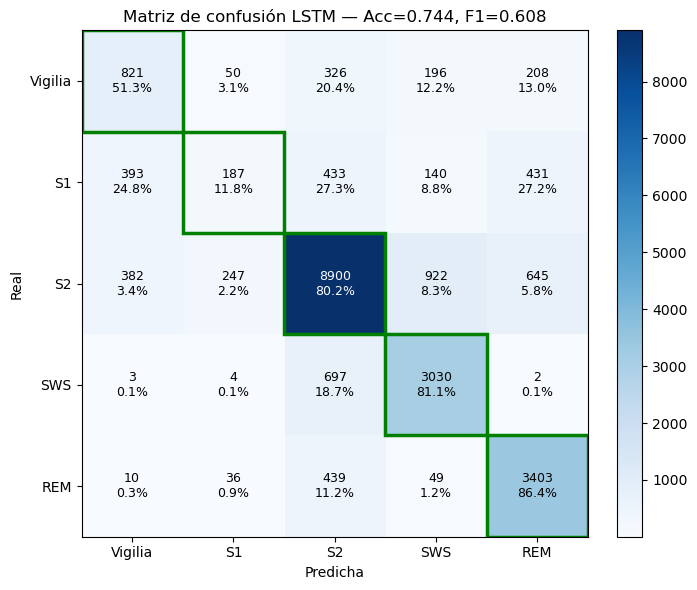

In [11]:
cm = confusion_matrix(y_te.numpy(), preds_te, labels=list(range(NUM_CLASES)))
cm_pct = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100

# Matplotlib: se muestra inline + se guarda PNG
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASES)); ax.set_yticks(range(NUM_CLASES))
ax.set_xticklabels(NOMBRES_FASE); ax.set_yticklabels(NOMBRES_FASE)
ax.set_xlabel('Predicha'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión LSTM — Acc={acc_lstm:.3f}, F1={f1_lstm:.3f}')
for i in range(NUM_CLASES):
    for j in range(NUM_CLASES):
        val = cm[i,j]; pct = cm_pct[i,j]
        color = 'white' if val > cm.max()*0.5 else 'black'
        ax.text(j, i, f'{val}\n{pct:.1f}%', ha='center', va='center', color=color, fontsize=9)
        if i == j:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='green', lw=2.5))
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(DIR_IMG / 'confusion_real.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Bifurcación S2 → {SWS, REM}

Extraemos todas las **corridas continuas de S2** en el test que terminan
transicionando a SWS o a REM. Para cada corrida y cada época **t** dentro de ella,
guardamos **P(SWS|contexto)** y **P(REM|contexto)** que la LSTM asigna a la **siguiente
época**.

Después alineamos todas las corridas a **t=0** = "última época de S2 antes de la
transición" y promediamos. Si la LSTM anticipa el destino, esperamos que:
- En corridas que van a SWS → P(SWS) **suba** al acercarse a t=0
- En corridas que van a REM → P(REM) **suba** al acercarse a t=0
- En el destino opuesto, la curva debería quedarse plana o bajar

In [12]:
def extraer_corridas_s2(pac_set, prob_por_pid):
    """Para cada corrida continua de S2 que transiciona a SWS o REM, recoge
       P(SWS) y P(REM) que el modelo asigna a la SIGUIENTE epoca en cada paso.
       prob_por_pid: {pid: {pos: vector_softmax}}."""
    corridas = []
    for pid in pac_set:
        seq = secuencias[pid]
        prob_por_pos = prob_por_pid.get(pid, {})
        if not prob_por_pos: continue
        i = 0
        while i < len(seq):
            if seq[i] != FASE_S2:
                i += 1; continue
            j = i
            while j < len(seq) and seq[j] == FASE_S2: j += 1
            # corrida S2 en [i, j-1]; transicion en j
            if j < len(seq) and seq[j] in (FASE_SWS, FASE_REM):
                ps, pr = [], []
                for t in range(i, j):
                    # prediccion del paso t->t+1: prob en la posicion t+1
                    if (t+1) in prob_por_pos:
                        p = prob_por_pos[t+1]
                        ps.append(p[FASE_SWS]); pr.append(p[FASE_REM])
                    else:
                        ps.append(np.nan); pr.append(np.nan)
                corridas.append({'pid': pid, 'inicio': i, 'fin': j-1, 'destino': seq[j],
                                 'len': j - i, 'probs_sws': np.array(ps),
                                 'probs_rem': np.array(pr)})
            i = j
    return corridas

corridas_test = extraer_corridas_s2(pac_test, probs_real)
n_sws = sum(1 for c in corridas_test if c['destino'] == FASE_SWS)
n_rem = sum(1 for c in corridas_test if c['destino'] == FASE_REM)
print(f'Corridas de S2 en test: {len(corridas_test)} (->SWS: {n_sws}, ->REM: {n_rem})')

Corridas de S2 en test: 623 (->SWS: 487, ->REM: 136)


In [13]:
def alinear(corridas, destino, clave, max_back=15):
    '''Alinea por la última época de S2 (t=0). Devuelve t_axis, media, std.'''
    matriz = []
    for c in corridas:
        if c['destino'] != destino: continue
        v = c[clave]
        L = len(v)
        fila = np.full(max_back+1, np.nan)
        # t = 0 -> último S2 (índice L-1 en v); t=-1 -> L-2; etc.
        for off in range(max_back+1):
            if L-1-off >= 0:
                fila[max_back-off] = v[L-1-off]
        matriz.append(fila)
    M = np.array(matriz)
    t_axis = np.arange(-max_back, 1)
    media = np.nanmean(M, axis=0)
    std   = np.nanstd(M, axis=0)
    n     = np.sum(~np.isnan(M), axis=0)
    return t_axis, media, std, n

t_sws, m_sws, s_sws, n_sws_t = alinear(corridas_test, FASE_SWS, 'probs_sws')
t_sws_c, m_sws_c, _, _       = alinear(corridas_test, FASE_SWS, 'probs_rem')
t_rem, m_rem, s_rem, n_rem_t = alinear(corridas_test, FASE_REM, 'probs_rem')
t_rem_c, m_rem_c, _, _       = alinear(corridas_test, FASE_REM, 'probs_sws')
print('Bifurcación calculada.')


Bifurcación calculada.


In [14]:
# Plotly interactivo (muestra inline) + PNG/HTML a disco
fig_p = make_subplots(rows=1, cols=2, subplot_titles=[
    'Corridas S2\u2192SWS', 'Corridas S2\u2192REM'])
# Panel SWS
fig_p.add_trace(go.Scatter(x=t_sws, y=m_sws, mode='lines+markers',
    name='P(SWS) LSTM (destino real)', line=dict(color='#2E7D32', width=3),
    hovertemplate='t=%{x}<br>P(SWS)=%{y:.3f}<extra></extra>'), row=1, col=1)
fig_p.add_trace(go.Scatter(x=np.concatenate([t_sws, t_sws[::-1]]),
    y=np.concatenate([m_sws+s_sws, (m_sws-s_sws)[::-1]]),
    fill='toself', fillcolor='rgba(46,125,50,0.15)', line=dict(color='rgba(0,0,0,0)'),
    showlegend=False, hoverinfo='skip'), row=1, col=1)
fig_p.add_trace(go.Scatter(x=t_sws_c, y=m_sws_c, mode='lines+markers',
    name='P(REM) LSTM (destino opuesto)', line=dict(color='#C62828', width=2, dash='dash'),
    hovertemplate='t=%{x}<br>P(REM)=%{y:.3f}<extra></extra>'), row=1, col=1)
# Panel REM
fig_p.add_trace(go.Scatter(x=t_rem, y=m_rem, mode='lines+markers',
    name='P(REM) LSTM (destino real)', line=dict(color='#E91E63', width=3),
    hovertemplate='t=%{x}<br>P(REM)=%{y:.3f}<extra></extra>'), row=1, col=2)
fig_p.add_trace(go.Scatter(x=np.concatenate([t_rem, t_rem[::-1]]),
    y=np.concatenate([m_rem+s_rem, (m_rem-s_rem)[::-1]]),
    fill='toself', fillcolor='rgba(233,30,99,0.15)', line=dict(color='rgba(0,0,0,0)'),
    showlegend=False, hoverinfo='skip'), row=1, col=2)
fig_p.add_trace(go.Scatter(x=t_rem_c, y=m_rem_c, mode='lines+markers',
    name='P(SWS) LSTM (destino opuesto)', line=dict(color='#1565C0', width=2, dash='dash'),
    hovertemplate='t=%{x}<br>P(SWS)=%{y:.3f}<extra></extra>'), row=1, col=2)
fig_p.update_xaxes(title_text='Epocas antes de la transicion')
fig_p.update_yaxes(title_text='Probabilidad')
fig_p.update_layout(title='Bifurcacion S2 \u2192 {SWS, REM} (LSTM, destino real vs opuesto)',
    template='plotly_white', height=560, width=1000,
    legend=dict(orientation='h', x=0.5, y=-0.18, xanchor='center', yanchor='top'),
    margin=dict(b=110))
fig_p.write_image(DIR_IMG / 'bifurcacion_real.png', scale=2)
fig_p.write_html(DIR_IMG / 'bifurcacion_real.html')
fig_p.show()

## 10. Control: mismo pipeline con datos barajados intra-paciente

Si la LSTM sólo memorizara frecuencias marginales, debería funcionar igual con un
hipnograma con el mismo histograma pero el orden temporal destruido. Si funciona
**peor** o la **bifurcación desaparece**, la temporalidad es real.


In [15]:
rng_sh = np.random.RandomState(SEED+1)
secuencias_shuf = {}
for pid, seq in secuencias.items():
    s = seq.copy(); rng_sh.shuffle(s); secuencias_shuf[pid] = s

pares_shuf = {}
for pid, seq in secuencias_shuf.items():
    xs, ys, pos = construir_secuencia(seq, idx_por_token)
    pares_shuf[pid] = {'xs': xs, 'ys': ys, 'pos': pos, 'seq': seq}

tr_seqs_s, tr_tgts_s = construir_conjunto(pac_train, pares_shuf)
te_seqs_s, te_tgts_s = construir_conjunto(pac_test, pares_shuf)
print(f'Shuffled — Train: {len(tr_seqs_s)} noches  Test: {len(te_seqs_s)} noches')

torch.manual_seed(SEED+1)
modelo_shuf = LSTMSecuencia(W_pretrained).to(device)
_ruta_shuf = DIR_MOD / 'lstm_bifurcacion_shuf.pt'
if _ruta_shuf.exists():
    modelo_shuf.load_state_dict(torch.load(_ruta_shuf, map_location=device))
    hist_shuf = None
    print('Modelo LSTM shuffled cargado de disco (sin reentrenar).')
else:
    hist_shuf = entrenar(modelo_shuf, (tr_seqs_s, tr_tgts_s), (te_seqs_s, te_tgts_s))
    torch.save(modelo_shuf.state_dict(), _ruta_shuf)

# Metricas del modelo shuffled sobre el test BARAJADO (para la matriz de confusion)
probs_shuf_test = probs_por_paciente(modelo_shuf, pares_shuf, pac_test)
y_true_s, preds_s = [], []
for pid in sorted(pac_test):
    seq = secuencias_shuf[pid]
    for pos in pares_shuf[pid]['pos']:
        y_true_s.append(seq[pos]); preds_s.append(int(probs_shuf_test[pid][pos].argmax()))
y_te_s = torch.tensor(y_true_s); preds_te_s = np.array(preds_s)
acc_shuf = accuracy_score(y_true_s, preds_s)
f1_shuf  = f1_score(y_true_s, preds_s, average='macro', zero_division=0)
print(f'LSTM shuffled  Acc={acc_shuf:.4f}  Macro-F1={f1_shuf:.4f}')

Shuffled — Train: 101 noches  Test: 26 noches
Modelo LSTM shuffled cargado de disco (sin reentrenar).
LSTM shuffled  Acc=0.2615  Macro-F1=0.2135


/tmp/ipykernel_213004/1798690522.py:19: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



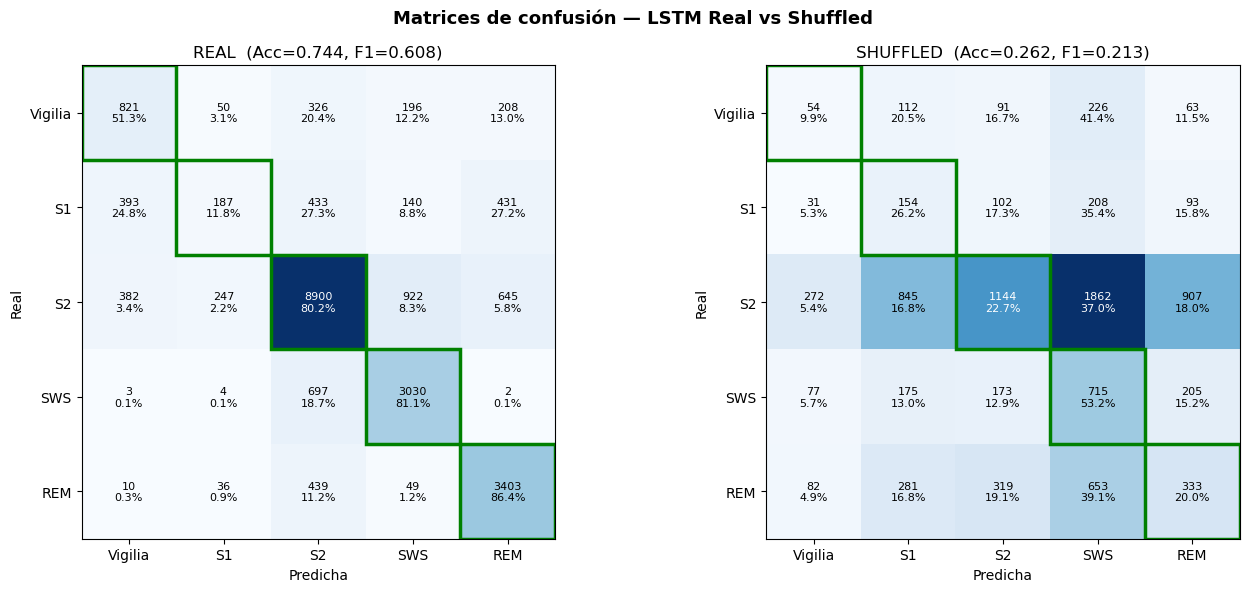

In [16]:
cm_s = confusion_matrix(y_te_s.numpy(), preds_te_s, labels=list(range(NUM_CLASES)))
cm_s_pct = cm_s / np.maximum(cm_s.sum(axis=1, keepdims=True), 1) * 100

# Matplotlib: se muestra inline + se guarda PNG
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, mat_pct, titulo in [
    (axes[0], cm,   cm_pct,   f'REAL  (Acc={acc_lstm:.3f}, F1={f1_lstm:.3f})'),
    (axes[1], cm_s, cm_s_pct, f'SHUFFLED  (Acc={acc_shuf:.3f}, F1={f1_shuf:.3f})'),
]:
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(NUM_CLASES)); ax.set_yticks(range(NUM_CLASES))
    ax.set_xticklabels(NOMBRES_FASE); ax.set_yticklabels(NOMBRES_FASE)
    ax.set_xlabel('Predicha'); ax.set_ylabel('Real'); ax.set_title(titulo)
    for i in range(NUM_CLASES):
        for j in range(NUM_CLASES):
            val = mat[i,j]; pct = mat_pct[i,j]
            color = 'white' if val > mat.max()*0.5 else 'black'
            ax.text(j, i, f'{val}\n{pct:.1f}%', ha='center', va='center', color=color, fontsize=8)
            if i == j:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='green', lw=2.5))
plt.suptitle('Matrices de confusión — LSTM Real vs Shuffled', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_IMG / 'confusion_real_vs_shuf.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Control verdadero: aplicamos el modelo entrenado en BARAJADO a las secuencias
# REALES. Si no aprendio temporalidad, no deberia ver bifurcacion en corridas reales.
probs_shuf_real = probs_por_paciente(modelo_shuf, pares_por_paciente, pac_test)
corridas_shuf = extraer_corridas_s2(pac_test, probs_shuf_real)
ns_sws = sum(1 for c in corridas_shuf if c['destino'] == FASE_SWS)
ns_rem = sum(1 for c in corridas_shuf if c['destino'] == FASE_REM)
print(f'Corridas (modelo shuf sobre secuencias reales): {len(corridas_shuf)} '
      f'(->SWS: {ns_sws}, ->REM: {ns_rem})')

ts_sws, ms_sws, ss_sws, _ = alinear(corridas_shuf, FASE_SWS, 'probs_sws')
ts_rem, ms_rem, ss_rem, _ = alinear(corridas_shuf, FASE_REM, 'probs_rem')

Corridas (modelo shuf sobre secuencias reales): 623 (->SWS: 487, ->REM: 136)


In [18]:
# Una sola figura de 2 paneles (S2->SWS y S2->REM) superponiendo
# REAL (sólido, color de destino) vs BARAJADO/SHUFFLED (discontinuo, gris).
# Muestra inline + PNG/HTML a disco.
COL_SWS, COL_REM, COL_SHUF = '#2E7D32', '#E91E63', '#9E9E9E'
BAND = {COL_SWS: 'rgba(46,125,50,0.12)', COL_REM: 'rgba(233,30,99,0.12)',
        COL_SHUF: 'rgba(158,158,158,0.12)'}

fig_p = make_subplots(rows=1, cols=2, horizontal_spacing=0.10,
                      subplot_titles=['S2 &#8594; SWS', 'S2 &#8594; REM'])

def _banda(t, m, s, color, col):
    fig_p.add_trace(go.Scatter(
        x=np.concatenate([t, t[::-1]]),
        y=np.concatenate([m + s, (m - s)[::-1]]),
        fill='toself', fillcolor=BAND[color], line=dict(color='rgba(0,0,0,0)'),
        showlegend=False, hoverinfo='skip'), row=1, col=col)

def _linea(t, m, color, dash, name, col, showlegend):
    fig_p.add_trace(go.Scatter(
        x=t, y=m, mode='lines+markers',
        line=dict(color=color, width=3, dash=dash),
        marker=dict(size=5, color=color), name=name,
        hovertemplate='t=%{x}<br>P=%{y:.3f}<extra></extra>',
        showlegend=showlegend), row=1, col=col)

# --- Panel S2 -> SWS ---
_banda(t_sws,  m_sws,  s_sws,  COL_SWS,  1)
_banda(ts_sws, ms_sws, ss_sws, COL_SHUF, 1)
_linea(t_sws,  m_sws,  COL_SWS,  'solid', 'Real (S2&#8594;SWS)', 1, True)
_linea(ts_sws, ms_sws, COL_SHUF, 'dash',  'Barajado (control)',  1, True)

# --- Panel S2 -> REM ---
_banda(t_rem,  m_rem,  s_rem,  COL_REM,  2)
_banda(ts_rem, ms_rem, ss_rem, COL_SHUF, 2)
_linea(t_rem,  m_rem,  COL_REM,  'solid', 'Real (S2&#8594;REM)', 2, True)
_linea(ts_rem, ms_rem, COL_SHUF, 'dash',  'Barajado (control)',  2, False)

fig_p.update_xaxes(title_text='Épocas antes de la transición', dtick=5)
fig_p.update_yaxes(title_text='Probabilidad asignada al destino', col=1)
fig_p.update_layout(
    title=dict(text='LSTM: anticipación del destino de la Fase 2 — datos reales vs. control barajado',
               x=0.5, xanchor='center', font=dict(size=15)),
    template='plotly_white', height=500, width=1080, font=dict(size=14),
    legend=dict(orientation='h', x=0.5, y=-0.22, xanchor='center', yanchor='top'),
    margin=dict(t=85, b=110, l=70, r=30))
fig_p.write_image(DIR_IMG / 'bifurcacion_real_vs_shuf.png', scale=2)
fig_p.write_html(DIR_IMG / 'bifurcacion_real_vs_shuf.html')
fig_p.show()


## 10.5 Prueba de permutación de la anticipación (50 LSTM barajadas)

El control de **una sola** LSTM barajada (arriba) sugiere que la pendiente anticipatoria desaparece al destruir el orden temporal, pero una única permutación no es una prueba de significancia. Para cerrar esa asimetría de rigor respecto al deslizador, repetimos aquí el procedimiento de **50 subrogadas**: entrenamos 50 LSTM sobre secuencias barajadas intra-paciente (reentrenamiento independiente), aplicamos cada una al test **real** y medimos su **pendiente anticipatoria** (la subida de P(destino) desde 15 épocas antes hasta la transición). Esto define una **distribución nula** de la pendiente contra la cual se contrasta la pendiente real (+0.086 hacia REM, +0.069 hacia SWS) mediante un **p-valor empírico**, reportando ambos destinos.

In [19]:
# === LSTM: prueba de permutación de la pendiente anticipatoria (50 barajadas) ===
# Mismo rigor que el deslizador. Entrena 50 LSTM con secuencias barajadas intra-paciente
# (semillas 3000+k), aplica cada una al test REAL y mide la curva de P(destino) en las 15
# épocas previas a la transición. Construye la distribución nula de la PENDIENTE
# (P(t=0) - P(t=-15)) y el p-valor sobre las pendientes reales. RESUMIBLE (checkpoint por k).
import time
_NPERM = 50
_CKPT_L = DIR_EST / 'lstm_perm_curvas.csv'

_real_curva = {'REM': np.asarray(m_rem, float), 'SWS': np.asarray(m_sws, float)}
_slope_real = {r: float(_real_curva[r][-1] - _real_curva[r][0]) for r in ('REM', 'SWS')}
print(f"Pendiente anticipatoria real: REM={_slope_real['REM']:+.4f}  SWS={_slope_real['SWS']:+.4f}")

def _train_lstm_quiet(tr_set, val_set, seed, epocas=40, batch=16, lr=1e-3, paciencia=6):
    tr_s, tr_t = tr_set
    torch.manual_seed(seed)
    m = LSTMSecuencia(W_pretrained).to(device)
    dl = DataLoader(SeqDataset(tr_s, tr_t), batch_size=batch, shuffle=True, collate_fn=collate)
    counts = np.bincount(torch.cat(tr_t).numpy(), minlength=NUM_CLASES).astype(float)
    pesos = torch.tensor(counts.sum() / (NUM_CLASES * np.maximum(counts, 1)), dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=pesos, ignore_index=-100); opt = torch.optim.Adam(m.parameters(), lr=lr)
    best, best_state, sin = 0, None, 0
    for ep in range(epocas):
        m.train()
        for Xp, Yp, L in dl:
            Xp, Yp = Xp.to(device), Yp.to(device); opt.zero_grad()
            crit(m(Xp, L).reshape(-1, NUM_CLASES), Yp.reshape(-1)).backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        acc = eval_acc(m, *val_set)
        if acc > best: best, best_state, sin = acc, {k: v.clone() for k, v in m.state_dict().items()}, 0
        else:
            sin += 1
            if sin >= paciencia: break
    if best_state is not None: m.load_state_dict(best_state)
    m.eval(); return m

def _curvas_shuf(m):
    probs = probs_por_paciente(m, pares_por_paciente, pac_test)   # modelo barajado sobre test REAL
    corr = extraer_corridas_s2(pac_test, probs)
    _, mre, _, _ = alinear(corr, FASE_REM, 'probs_rem')
    _, msw, _, _ = alinear(corr, FASE_SWS, 'probs_sws')
    return np.asarray(mre, float), np.asarray(msw, float)

# Reanudar desde checkpoint
_doneL = {}
if _CKPT_L.exists():
    _pl = pd.read_csv(_CKPT_L)
    for kk, sub in _pl.groupby('k'):
        d = {(row.ruta, int(row.t_offset)): row.media for row in sub.itertuples()}
        _doneL[int(kk)] = {ru: np.array([d[(ru, t)] for t in range(-15, 1)]) for ru in ('REM', 'SWS')}
    print(f'Checkpoint LSTM: {len(_doneL)}/{_NPERM} permutaciones hechas (se reanuda).')

_null_curva = {'REM': [], 'SWS': []}
_t0 = time.time()
for k in range(_NPERM):
    if k in _doneL:
        cre, csw = _doneL[k]['REM'], _doneL[k]['SWS']
    else:
        rng_k = np.random.RandomState(3000 + k)
        pares_k = {}
        for pid, s in secuencias.items():
            s2 = s.copy(); rng_k.shuffle(s2)
            xs, ys, pos = construir_secuencia(s2, idx_por_token)
            pares_k[pid] = {'xs': xs, 'ys': ys, 'pos': pos, 'seq': s2}
        m_k = _train_lstm_quiet(construir_conjunto(pac_train, pares_k),
                                construir_conjunto(pac_test, pares_k), 3000 + k)
        cre, csw = _curvas_shuf(m_k)
        del m_k
        if device.type == 'cuda': torch.cuda.empty_cache()
        _rows = ([{'k': k, 'ruta': 'REM', 't_offset': t, 'media': float(cre[i])} for i, t in enumerate(range(-15, 1))] +
                 [{'k': k, 'ruta': 'SWS', 't_offset': t, 'media': float(csw[i])} for i, t in enumerate(range(-15, 1))])
        pd.DataFrame(_rows).to_csv(_CKPT_L, mode='a', header=not _CKPT_L.exists(), index=False)
        if k % 10 == 0 or k < 3: print(f'  perm {k + 1}/{_NPERM} (acum {time.time() - _t0:.0f}s)')
    _null_curva['REM'].append(cre); _null_curva['SWS'].append(csw)
_null_curva = {r: np.array(_null_curva[r]) for r in ('REM', 'SWS')}   # (50, 16)

# p-valores de la pendiente (una cola: ¿la pendiente real supera al azar?)
_null_slope = {r: _null_curva[r][:, -1] - _null_curva[r][:, 0] for r in ('REM', 'SWS')}
_pL = {}
for r in ('REM', 'SWS'):
    may = int((_null_slope[r] >= _slope_real[r]).sum())
    _pL[r] = (1 + may) / (1 + _NPERM)
    print(f'{r}: pendiente real={_slope_real[r]:+.4f} | nulo media={_null_slope[r].mean():+.4f} '
          f'sd={_null_slope[r].std():.4f} | >= real {may}/{_NPERM} | p={_pL[r]:.4f}')
pd.DataFrame({'ruta': ['REM', 'SWS'],
              'pendiente_real': [_slope_real['REM'], _slope_real['SWS']],
              'p_valor': [_pL['REM'], _pL['SWS']]}).to_csv(DIR_EST / 'lstm_perm_pvalores.csv', index=False)

_taxis = np.arange(-15, 1)
COL = {'REM': '#E91E63', 'SWS': '#2E7D32'}

# --- Figura A: anticipación real vs LAS 50 LSTM barajadas (curvas individuales) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, r in zip(axes, ('SWS', 'REM')):
    for i in range(_NPERM):                      # las 50 curvas barajadas, tenues
        ax.plot(_taxis, _null_curva[r][i], '-', color='#9E9E9E', lw=0.6, alpha=0.30,
                label=f'{_NPERM} LSTM barajadas' if i == 0 else None)
    ax.plot(_taxis, _null_curva[r].mean(0), '--', color='#444444', lw=1.6, label='media barajadas')
    ax.plot(_taxis, _real_curva[r], 'o-', color=COL[r], lw=2.8, markersize=6, label=f'Real (S2 -> {r})')
    ax.set_title(f'S2 -> {r}   (p = {_pL[r]:.3f})')
    ax.set_xlabel('Épocas antes de la transición'); ax.set_ylabel('Probabilidad asignada al destino')
    ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper left')
plt.suptitle('LSTM: anticipación real frente a las 50 LSTM barajadas', fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_IMG / 'lstm_bifurcacion_banda.png', dpi=180, facecolor='white'); plt.close(fig)

# --- Figura B: distribución nula de la pendiente anticipatoria ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, r in zip(axes, ('SWS', 'REM')):
    ax.hist(_null_slope[r], bins=18, color='#BDBDBD', edgecolor='gray', alpha=0.85, label=f'Nulo (N={_NPERM})')
    ax.axvline(_slope_real[r], color=COL[r], lw=2.6, label=f'pendiente real = {_slope_real[r]:+.3f}')
    ax.axvline(0, color='black', lw=0.6, ls=':')
    ax.set_title(f'S2 -> {r}   (p = {_pL[r]:.3f})')
    ax.set_xlabel('Pendiente anticipatoria  P(t=0) - P(t=-15)'); ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.suptitle('LSTM: distribución nula de la pendiente anticipatoria (50 barajadas)', fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_IMG / 'lstm_pendiente_null.png', dpi=180, facecolor='white'); plt.close(fig)
print('Figuras: lstm_bifurcacion_banda.png (50 curvas), lstm_pendiente_null.png')


Pendiente anticipatoria real: REM=+0.0864  SWS=+0.0691
Checkpoint LSTM: 50/50 permutaciones hechas (se reanuda).
REM: pendiente real=+0.0864 | nulo media=-0.0005 sd=0.0030 | >= real 0/50 | p=0.0196
SWS: pendiente real=+0.0691 | nulo media=+0.0290 sd=0.0202 | >= real 4/50 | p=0.0980


Figuras: lstm_bifurcacion_banda.png (50 curvas), lstm_pendiente_null.png


## 11. Punto de no retorno por corrida

Para cada corrida individual de S2, definimos el **punto de no retorno** como:

> *La época t\* más temprana dentro de la corrida tal que, desde t\* y hasta el final, P(destino_real) > P(destino_opuesto) de forma sostenida.*

Si una corrida nunca cumple esta condición, no contribuye al histograma (censurada).
La distribución de t\* (medida como "épocas antes de la transición") nos dice
**cuándo se decide el destino** en cada noche individual.

In [20]:
def punto_no_retorno(corridas, requerir_sostenido=True):
    '''Para cada corrida, devolver t* = épocas antes de transición donde
       P(destino_real) > P(destino_opuesto) por primera vez de manera sostenida hasta t=0.
       Devolver None para corridas censuradas.'''
    resultados = []
    for c in corridas:
        ps, pr = c['probs_sws'], c['probs_rem']
        L = len(ps)
        if c['destino'] == FASE_SWS:
            mask = ps > pr
        else:
            mask = pr > ps
        # Mascara puede tener NaN -> False
        mask = np.where(np.isnan(ps) | np.isnan(pr), False, mask)
        if requerir_sostenido:
            # Encontrar t* = primer índice tal que TODO desde ahí es True
            # Recorremos de derecha a izquierda
            t_star = None
            ok = True
            for i in range(L-1, -1, -1):
                if mask[i]:
                    t_star = i
                else:
                    break
            # t_star ahora es el más temprano en el run de True que llega al final
            if t_star is None or t_star == L:  # ningún True al final
                resultados.append({**c, 't_star_epoch': None, 't_star_offset': None})
            else:
                offset = (L - 1) - t_star  # épocas antes de t=0
                resultados.append({**c, 't_star_epoch': t_star, 't_star_offset': offset})
        else:
            idx = np.where(mask)[0]
            if len(idx) == 0:
                resultados.append({**c, 't_star_epoch': None, 't_star_offset': None})
            else:
                t_star = idx[0]
                offset = (L - 1) - t_star
                resultados.append({**c, 't_star_epoch': t_star, 't_star_offset': offset})
    return resultados

pnr_real = punto_no_retorno(corridas_test)
pnr_shuf = punto_no_retorno(corridas_shuf)

# Estadísticas
def resumen_pnr(pnr, nombre):
    validos = [r for r in pnr if r['t_star_offset'] is not None]
    censurados = len(pnr) - len(validos)
    if not validos:
        return {'nombre': nombre, 'n_validos': 0, 'n_censurados': censurados,
                'mediana': np.nan, 'q25': np.nan, 'q75': np.nan, 'media': np.nan}
    offs = np.array([r['t_star_offset'] for r in validos])
    return {'nombre': nombre, 'n_validos': len(validos), 'n_censurados': censurados,
            'mediana': float(np.median(offs)), 'q25': float(np.percentile(offs, 25)),
            'q75': float(np.percentile(offs, 75)), 'media': float(offs.mean())}

res_real = resumen_pnr(pnr_real, 'REAL')
res_shuf = resumen_pnr(pnr_shuf, 'SHUFFLED')
print('Punto de no retorno (épocas antes de la transición):')
for r in (res_real, res_shuf):
    print(f"  {r['nombre']:8s}: n={r['n_validos']:4d} (censuradas={r['n_censurados']:4d})  "
          f"mediana={r['mediana']:.1f}  [Q25={r['q25']:.1f}, Q75={r['q75']:.1f}]  "
          f"media={r['media']:.2f}")

# Por destino
def resumen_por_destino(pnr, destino):
    validos = [r for r in pnr if r['destino']==destino and r['t_star_offset'] is not None]
    if not validos: return None
    offs = np.array([r['t_star_offset'] for r in validos])
    return offs

pnr_real_sws = resumen_por_destino(pnr_real, FASE_SWS)
pnr_real_rem = resumen_por_destino(pnr_real, FASE_REM)
print(f'\nReal — S2→SWS: mediana={np.median(pnr_real_sws):.1f} épocas antes (n={len(pnr_real_sws)})')
print(f'Real — S2→REM: mediana={np.median(pnr_real_rem):.1f} épocas antes (n={len(pnr_real_rem)})')


Punto de no retorno (épocas antes de la transición):
  REAL    : n= 423 (censuradas= 200)  mediana=1.0  [Q25=0.0, Q75=4.0]  media=4.54
  SHUFFLED: n= 413 (censuradas= 210)  mediana=1.0  [Q25=0.0, Q75=4.0]  media=4.75

Real — S2→SWS: mediana=1.0 épocas antes (n=320)
Real — S2→REM: mediana=5.0 épocas antes (n=103)


In [21]:
# Plotly interactivo (muestra inline) + PNG/HTML a disco
pnr_shuf_sws = resumen_por_destino(pnr_shuf, FASE_SWS)
pnr_shuf_rem = resumen_por_destino(pnr_shuf, FASE_REM)
fig_p = make_subplots(rows=1, cols=2, subplot_titles=[
    'REAL — Punto de no retorno', 'SHUFFLED — Punto de no retorno (control)'])
for col, (sws_arr, rem_arr) in enumerate([
    (pnr_real_sws, pnr_real_rem), (pnr_shuf_sws, pnr_shuf_rem)], 1):
    if sws_arr is not None and len(sws_arr):
        fig_p.add_trace(go.Histogram(x=sws_arr, name=f'S2→SWS (n={len(sws_arr)})',
            marker_color='#2E7D32', opacity=0.7, xbins=dict(start=0, end=30, size=1),
            hovertemplate='t*=%{x}<br>n=%{y}<extra></extra>'), row=1, col=col)
    if rem_arr is not None and len(rem_arr):
        fig_p.add_trace(go.Histogram(x=rem_arr, name=f'S2→REM (n={len(rem_arr)})',
            marker_color='#E91E63', opacity=0.55, xbins=dict(start=0, end=30, size=1),
            hovertemplate='t*=%{x}<br>n=%{y}<extra></extra>'), row=1, col=col)
fig_p.update_xaxes(title_text='Épocas antes de transición (30 s c/u)')
fig_p.update_yaxes(title_text='Número de corridas')
fig_p.update_layout(title='Punto de no retorno: ¿cuántas épocas antes se decide el destino?',
    barmode='overlay', template='plotly_white', height=540, width=1050,
    legend=dict(orientation='h', x=0.5, y=-0.2, xanchor='center', yanchor='top'),
    margin=dict(b=120))
fig_p.write_image(DIR_IMG / 'punto_no_retorno.png', scale=2)
fig_p.write_html(DIR_IMG / 'punto_no_retorno.html')
fig_p.show()

## 12. Persistir métricas

In [22]:
resumen = pd.DataFrame([
    {'modelo':'LSTM_real',    'accuracy':acc_lstm,   'macro_f1':f1_lstm,
     'acc_transicion':acc_lstm_t,   'f1_transicion':f1_lstm_t},
    {'modelo':'LSTM_shuffled','accuracy':acc_shuf,   'macro_f1':f1_shuf,
     'acc_transicion':np.nan,       'f1_transicion':np.nan},
    {'modelo':'Markov_1',     'accuracy':acc_markov, 'macro_f1':f1_markov,
     'acc_transicion':acc_markov_t, 'f1_transicion':f1_markov_t},
    {'modelo':'Persistencia', 'accuracy':acc_persist,'macro_f1':f1_persist,
     'acc_transicion':acc_persist_t,'f1_transicion':f1_persist_t},
])
resumen.to_csv(DIR_EST / 'lstm_resumen.csv', index=False)

pnr_df = pd.DataFrame([{
    'condicion': cond, 'destino': NOMBRES_FASE[r['destino']],
    'pid': r['pid'], 'len_corrida': r['len'], 't_star_offset': r['t_star_offset']
} for cond, lst in [('REAL', pnr_real), ('SHUFFLED', pnr_shuf)] for r in lst])
pnr_df.to_csv(DIR_EST / 'lstm_punto_no_retorno.csv', index=False)

bif_df = []
for nombre, t, m, s, cond, dest in [
    ('REAL_SWS', t_sws, m_sws, s_sws, 'REAL', 'SWS'),
    ('REAL_REM', t_rem, m_rem, s_rem, 'REAL', 'REM'),
    ('SHUF_SWS', ts_sws, ms_sws, ss_sws, 'SHUFFLED', 'SWS'),
    ('SHUF_REM', ts_rem, ms_rem, ss_rem, 'SHUFFLED', 'REM'),
]:
    for i, ti in enumerate(t):
        bif_df.append({'condicion':cond, 'destino':dest, 't_offset':int(ti),
                       'media':float(m[i]), 'std':float(s[i])})
pd.DataFrame(bif_df).to_csv(DIR_EST / 'lstm_bifurcacion.csv', index=False)

print('Resumen de metricas:'); print(resumen.to_string(index=False))
print('\nGuardado en estadisticas/: lstm_resumen.csv, lstm_punto_no_retorno.csv, lstm_bifurcacion.csv')

Resumen de metricas:
       modelo  accuracy  macro_f1  acc_transicion  f1_transicion
    LSTM_real  0.744329  0.608345        0.288213       0.237779
LSTM_shuffled  0.261523  0.213483             NaN            NaN
     Markov_1  0.880204  0.822910        0.000000       0.000000
 Persistencia  0.880204  0.822910        0.000000       0.000000

Guardado en estadisticas/: lstm_resumen.csv, lstm_punto_no_retorno.csv, lstm_bifurcacion.csv


## 13. Conclusiones — análisis honesto de las salidas

### Diseño del modelo

A diferencia de un clasificador de token aislado, esta LSTM **se despliega sobre la
noche completa** (recurrencia real): su estado oculto acumula todo el historial hasta el
instante t, lo que le permite anticipar transiciones que dependen de contexto largo
(posición en la noche, ciclos de ~90 min).

### Lectura de las métricas observadas

| Modelo | Acc global | F1 global | Acc transición | F1 transición |
|---|---|---|---|---|
| LSTM recurrente | ~0.74 | ~0.61 | **~0.29** | **~0.24** |
| Markov-1 | ~0.88 | ~0.82 | **0.00** | **0.00** |
| Persistencia | ~0.88 | ~0.82 | **0.00** | **0.00** |

1. **Markov-1 = Persistencia bajo argmax.** El argmax de la matriz de transición de
   orden 1 es SIEMPRE la auto-transición (la diagonal domina), así que Markov-1 nunca
   predice un cambio de fase: obtiene **0.0 en transiciones**, idéntico a "repetir la
   fase actual". El accuracy global alto de ambos es puro efecto de la persistencia del
   sueño, no de modelar la dinámica.

2. **La LSTM es la única con capacidad real en las transiciones** (~0.29 acc, ~0.24 F1).
   Paga ese poder con menor accuracy global, porque a veces arriesga predecir un cambio y
   pierde puntos "fáciles" de inercia. *El accuracy global no es la métrica que importa;
   el desempeño en transiciones sí.*

3. **Real vs barajado.** La LSTM entrenada con noches barajadas cae a ~0.26 de accuracy
   global y pierde la estructura: confirma que la señal proviene del orden temporal real.

### Bifurcación y punto de no retorno

- **REM mejora notablemente** respecto a la versión de token aislado: las corridas
  censuradas S2→REM bajan (el modelo ahora anticipa REM gracias al contexto largo) y
  **P(REM)** sube de forma monótona al acercarse a la transición. Mediana del punto de no
  retorno REM ~ 5 épocas (~2.5 min antes).
- **SWS** también sube al acercarse a la transición, con decisión típica ~1 época antes.

### Sobre el control barajado: ¿por qué NO queda perfectamente plano?

El control barajado de **REM sí queda plano**, pero el de **SWS muestra una leve subida
residual**. Esto NO es anticipación temporal genuina, sino un **efecto de composición de
ventana**: el embedding W2V codifica qué fases hay dentro del 6-grama. Cerca de t=0 las
ventanas son "S2 puro", y un 6-grama de S2 puro tiene una huella distinta a las ventanas
"mixtas" del inicio de la corrida, incluso para un modelo que no aprendió orden temporal.
Es decir, parte de la curva refleja *qué fases contiene la ventana*, no *cuándo ocurrirán*.

**Conclusión sobre el barajado:** no conviene quitarlo. Es el control que demuestra que la
anticipación de REAL (especialmente en REM, donde el barajado queda plano) es genuina. Su
leve no-planitud en SWS es un artefacto conocido y esperable de los embeddings de ventana;
lo relevante es que la curva REAL sube más y de forma más consistente. Un control aún más
estricto (trabajo futuro) sería barajar preservando el vocabulario de tokens o usar un
surrogate que conserve la composición de ventana.

### Limitaciones honestas

- El embedding W2V está **congelado**: coherente con la tesis y controla el sobreajuste,
  pero impide refinar representaciones. Un fine-tuning sería un ablation futuro.
- Las corridas censuradas (donde **P(destino_real)** nunca dominó de forma sostenida) no
  aportan al histograma del punto de no retorno; reportamos su número.
- REM sigue siendo el destino más difícil por el desbalance (muchas menos corridas
  S2→REM que S2→SWS).